<a href="https://colab.research.google.com/github/Cristiand056/practicas_IA/blob/main/weatherAUS_rainfall_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sandhyapalaniappan/rainfall-prediction-dataset-cleaned-weatheraus")

print("Path to dataset files:", path)

100%|██████████| 4.18M/4.18M [00:00<00:00, 87.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sandhyapalaniappan/rainfall-prediction-dataset-cleaned-weatheraus/versions/1


In [8]:
import os
os.listdir(path)

['weatherAUS_rainfall_prediction_dataset_cleaned.csv']

In [9]:
file_path = os.path.join(path, 'weatherAUS_rainfall_prediction_dataset_cleaned.csv')

In [5]:
import pandas as pd
import numpy as np

In [10]:
data = pd.read_csv(file_path)

In [11]:
data.sample(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
108164,2009-07-17,SalmonGums,9.8,16.3,1.0,5.47,7.61,W,52.00,WNW,...,69.0,54.0,1017.65,1015.26,4.45,4.51,12.8,15.4,No,No
83282,2014-07-14,Nuriootpa,4.0,9.3,0.0,3.10,0.40,ENE,33.00,NE,...,80.0,75.0,1029.70,1023.50,7.00,7.00,4.9,7.7,No,No
112845,2009-11-23,Sydney,19.9,22.8,0.0,13.40,0.30,W,40.04,SSE,...,62.0,68.0,1021.00,1022.60,7.00,8.00,21.4,20.4,No,No
131927,2010-04-30,Watsonia,11.8,15.6,1.0,3.60,0.00,WSW,17.00,WSW,...,94.0,82.0,1028.20,1026.40,8.00,7.00,12.2,14.9,No,No
30980,2010-11-21,Canberra,7.5,26.8,0.0,4.60,12.40,ENE,43.00,SW,...,61.0,19.0,1023.90,1020.70,0.00,1.00,17.9,25.9,No,No
87602,2016-06-02,PearceRAAF,11.9,21.4,0.0,5.47,9.20,ENE,46.00,ENE,...,57.0,44.0,1020.40,1015.50,4.45,4.51,14.3,20.9,No,No
80873,2016-12-01,NorfolkIsland,17.8,23.4,0.0,11.40,7.61,E,43.00,E,...,67.0,70.0,1012.90,1011.70,5.00,4.00,22.6,21.5,No,No
31786,2014-02-08,Cobar,23.5,39.8,0.0,14.20,7.61,NNE,65.00,N,...,20.0,8.0,1013.80,1010.80,0.00,1.00,30.9,38.8,No,No
48703,2008-09-24,Hobart,7.6,16.8,0.2,2.00,6.10,NW,54.00,NW,...,58.0,39.0,1022.50,1021.90,7.00,7.00,11.5,15.5,No,No
70045,2012-03-31,MountGinini,6.3,17.0,0.2,5.47,7.61,SW,48.00,W,...,76.0,59.0,1017.65,1015.26,4.45,4.51,8.8,16.1,No,No


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [22]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [24]:
data["Date"] = pd.to_datetime(data["Date"])

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [18]:
px.scatter(data, x='MinTemp', y='MaxTemp', color='RainTomorrow')

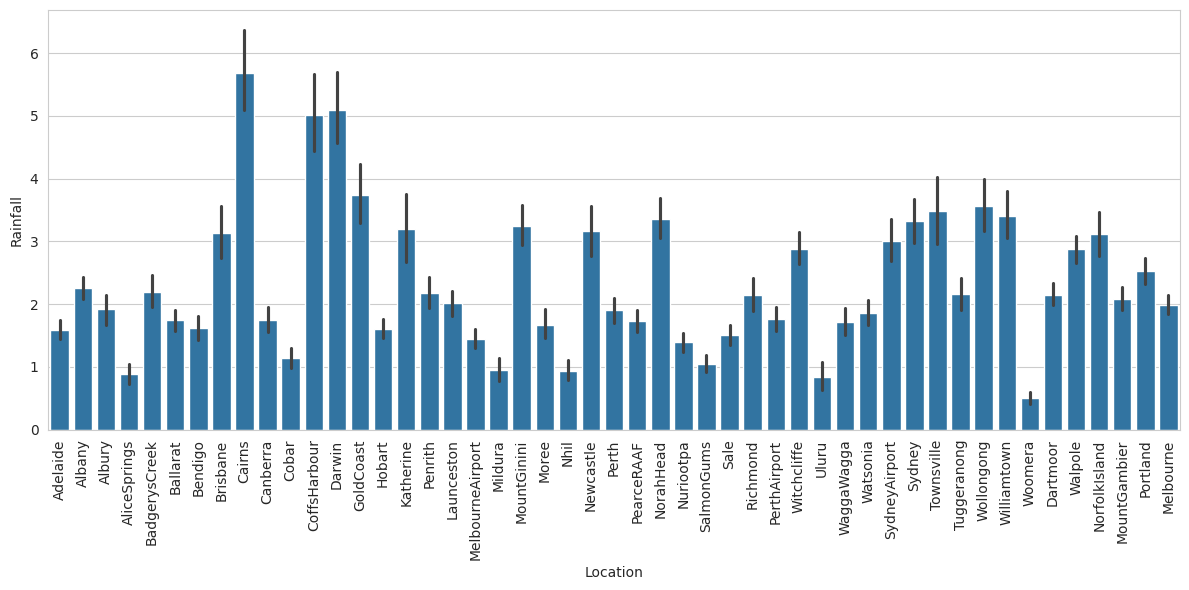

In [38]:
order = data.groupby('Location')["Rainfall"].median().sort_values().index
plt.figure(figsize=(12, 6))
sns.barplot(x='Location', y='Rainfall', data=data, order=order)
sns.set_style('whitegrid')
plt.xticks(rotation=90)
plt.tight_layout()

In [51]:
data["Date"] = pd.to_datetime(data["Date"])

data_2017_2014 = data[data["Date"].dt.year > 2013]

data_2017_2014_monthly = data_2017_2014.groupby(pd.Grouper(key="Date", freq="M"))["Rainfall"].mean().reset_index()


fig = px.line(data_2017_2014_monthly,x="Date",y="Rainfall",title="Caidad promedio de lluvias por mes, en los ultimos años")
fig.show()

#Limpiando el dataset, para entrenar el modelo

In [52]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day

In [53]:
data = data.drop("Date", axis=1)

In [54]:
data.sample(10)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
96454,PerthAirport,12.7,33.0,0.0,9.40,11.70,SW,33.0,S,SW,...,1013.0,0.00,1.00,23.5,31.8,No,No,2015,3,10
21085,Bendigo,13.3,25.0,0.2,5.40,7.61,SSE,56.0,SSE,SE,...,1018.0,4.45,4.51,17.1,23.8,No,No,2013,3,1
2771,Adelaide,6.0,14.8,1.2,1.80,7.61,NW,31.0,NNE,NW,...,1025.0,4.45,4.51,8.3,14.4,Yes,Yes,2012,7,19
54328,Melbourne,9.9,16.0,0.0,3.00,9.10,N,69.0,N,N,...,1018.2,3.00,1.00,10.8,15.1,No,No,2013,7,3
63867,Moree,6.1,21.0,0.0,4.00,9.80,SSW,31.0,SSW,SSW,...,1021.0,0.00,3.00,11.9,20.0,No,No,2013,5,25
136581,Witchcliffe,16.7,38.0,0.0,5.47,7.61,NNW,41.0,NNE,NW,...,1002.7,4.45,4.51,31.2,35.2,No,Yes,2011,12,29
134670,Williamtown,14.9,31.0,0.0,6.80,7.10,S,31.0,WNW,SE,...,1013.1,6.00,8.00,21.9,30.3,No,Yes,2010,2,28
66683,MountGambier,6.4,17.6,0.0,3.00,5.30,SW,28.0,NNW,WSW,...,1024.8,7.00,6.00,11.3,17.5,No,No,2013,4,29
58608,MelbourneAirport,17.1,33.8,0.0,14.60,11.60,N,74.0,NW,SSE,...,1006.7,7.00,6.00,31.6,31.4,No,No,2009,11,19
8241,Albury,5.1,11.3,5.4,5.47,7.61,W,30.0,ESE,W,...,1004.3,8.00,8.00,5.9,8.6,Yes,Yes,2015,7,12


In [55]:
X = data.drop("RainTomorrow", axis=1)
y = data["RainTomorrow"]

In [57]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import make_column_transformer

In [58]:
variables_categoricas = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]

one_hot = make_column_transformer(
    (OneHotEncoder(drop="if_binary", handle_unknown="ignore"), variables_categoricas),
    remainder="passthrough",
    sparse_threshold=0
)

In [59]:
X_encoded = one_hot.fit_transform(X)

In [60]:
X_encoded

array([[1.000e+00, 0.000e+00, 0.000e+00, ..., 2.010e+03, 4.000e+00,
        3.000e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 2.014e+03, 7.000e+00,
        2.200e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 2.014e+03, 7.000e+00,
        2.300e+01],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.012e+03, 1.000e+00,
        1.600e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.012e+03, 1.000e+00,
        1.800e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.017e+03, 1.000e+00,
        1.000e+01]])

In [62]:
feature_names = one_hot.get_feature_names_out()

X_transformed = pd.DataFrame(X_encoded, columns=feature_names)

X_transformed.index = X.index

X_transformed.sample(10)

,onehotencoder__Location_Adelaide,onehotencoder__Location_Albany,onehotencoder__Location_Albury,onehotencoder__Location_AliceSprings,onehotencoder__Location_BadgerysCreek,onehotencoder__Location_Ballarat,onehotencoder__Location_Bendigo,onehotencoder__Location_Brisbane,onehotencoder__Location_Cairns,onehotencoder__Location_Canberra,...,remainder__Humidity3pm,remainder__Pressure9am,remainder__Pressure3pm,remainder__Cloud9am,remainder__Cloud3pm,remainder__Temp9am,remainder__Temp3pm,remainder__Year,remainder__Month,remainder__Day
102480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80.0,1018.6,1016.9,7.00,8.00,17.4,18.7,2016.0,3.0,21.0
39508,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80.0,1028.8,1026.5,4.45,4.51,12.8,14.6,2010.0,4.0,30.0
87341,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,50.0,1002.0,999.8,1.00,4.51,29.3,30.1,2011.0,1.0,5.0
40162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,34.0,1011.5,1007.5,5.00,7.00,28.3,33.8,2009.0,4.0,22.0
125449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.0,1015.1,1012.6,6.00,7.00,21.2,23.7,2015.0,11.0,4.0
135888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,67.0,1014.6,1013.4,7.00,8.00,21.7,24.3,2011.0,3.0,18.0
92919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,39.0,1018.3,1017.3,1.00,1.00,26.0,32.5,2015.0,2.0,9.0
24798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,95.0,1012.6,1010.8,7.00,8.00,24.1,24.4,2010.0,3.0,25.0
17485,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,46.0,1022.6,1019.8,6.00,4.51,16.8,26.1,2009.0,10.0,29.0
41426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.0,1013.2,1010.1,7.00,7.00,28.7,32.6,2013.0,5.0,4.0


In [63]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=200)

In [80]:
model_arbol = Pipeline(steps=[
    ("preprocessor", one_hot),
    ("classifier", RandomForestClassifier(random_state=200, class_weight="balanced"))
])

model_arbol.fit(X_train, y_train)
y_pred = model_arbol.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("R2 Score:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8547710710848343
R2 Score: 0.151653662704599
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22713
           1       0.78      0.47      0.59      6379

    accuracy                           0.85     29092
   macro avg       0.82      0.72      0.75     29092
weighted avg       0.85      0.85      0.84     29092



In [84]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

modelo_arbol = ImbPipeline(steps=[
    ("preprocessor", one_hot),
    ("smote", SMOTE(random_state=200)),
    ("classifier", RandomForestClassifier(random_state=200, class_weight="balanced", n_estimators=400, max_depth=5))
])

model_arbol.fit(X_train, y_train)
y_pred = model_arbol.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("R2 Score:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8547710710848343
R2 Score: 0.7172556677868352
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22713
           1       0.78      0.47      0.59      6379

    accuracy                           0.85     29092
   macro avg       0.82      0.72      0.75     29092
weighted avg       0.85      0.85      0.84     29092



In [85]:
from xgboost import XGBClassifier

In [91]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

modelo_xgboost = ImbPipeline(steps=[
    ("onehot", one_hot),
    ("smote", SMOTE(random_state=42)),
    ("xgb", xgb)
])

modelo_xgboost.fit(X_train, y_train)

y_pred = modelo_xgboost.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8591365323800357
              precision    recall  f1-score   support

          No       0.88      0.95      0.91     22713
         Yes       0.74      0.55      0.63      6379

    accuracy                           0.86     29092
   macro avg       0.81      0.75      0.77     29092
weighted avg       0.85      0.86      0.85     29092



In [92]:
from sklearn.model_selection import RandomizedSearchCV

In [94]:
param_dist = {
    "xgb__n_estimators": [200, 300, 400],
    "xgb__max_depth": [3, 5, 7, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.6, 0.8, 1.0],
    "xgb__colsample_bytree": [0.6, 0.8, 1.0],
    "xgb__gamma": [0, 1, 5],
    "xgb__scale_pos_weight": [1, (len(y_train) - sum(y_train)) / sum(y_train)]
}


search = RandomizedSearchCV(
    modelo_xgboost,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)
print("Mejor score:", search.best_score_)

# Evaluar en test
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros: {'xgb__subsample': 1.0, 'xgb__scale_pos_weight': 1, 'xgb__n_estimators': 400, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.8}
Mejor score: 0.7768579484368751
Accuracy: 0.8627113983225629
              precision    recall  f1-score   support

          No       0.89      0.94      0.91     22713
         Yes       0.74      0.58      0.65      6379

    accuracy                           0.86     29092
   macro avg       0.81      0.76      0.78     29092
weighted avg       0.86      0.86      0.86     29092

